# Analyze and Visualize Text Categories
This notebook aims to understand and visualize the variable of interest, **'catégories'**, using text data from the `theme_text.csv` dataset.

## Section 1: Load and Explore the Dataset
Load the dataset into a Pandas DataFrame, display the first few rows, and check for missing values in the 'category' column.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Load the dataset
df_theme = pd.read_csv('theme_text.csv')

# Display the first few rows
df_theme.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [2]:
# Check for missing values in the 'category' column
missing_values = df_theme['category'].isnull().sum()
print(f"Missing values in 'category': {missing_values}")

Missing values in 'category': 0


## Section 2: Analyze Category Distribution
Use Pandas to calculate the frequency of each category and display the counts.

In [3]:
# Calculate the frequency of each category
category_counts = df_theme['category'].value_counts()
print("Category Counts:")
print(category_counts)

Category Counts:
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: category, dtype: int64


## Section 3: Visualize Category Distribution
Create a bar plot using Matplotlib or Seaborn to visualize the distribution of categories.

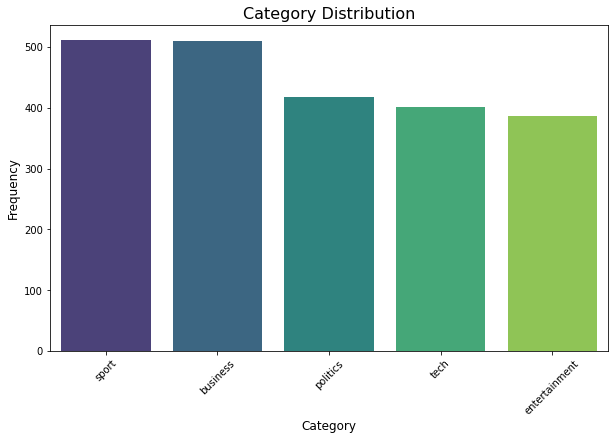

In [4]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for category distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")
plt.title("Category Distribution", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.show()

## Section 4: Identify Top Words per Category
Preprocess the text data (e.g., remove stopwords, tokenize) and identify the most frequent words for each category using libraries like NLTK or Scikit-learn.

In [6]:
# Import libraries for text preprocessing
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# Download stopwords if not already downloaded
nltk.download('stopwords')

# Define a function to preprocess text
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokens = text.lower().split()
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing to the 'text' column
df_theme['cleaned_text'] = df_theme['text'].apply(preprocess_text)

# Identify top words per category
vectorizer = CountVectorizer(max_features=10)
for category in df_theme['category'].unique():
    category_texts = df_theme[df_theme['category'] == category]['cleaned_text']
    word_counts = vectorizer.fit_transform(category_texts).toarray().sum(axis=0)
    top_words = vectorizer.get_feature_names()
    print(f"Top words for category '{category}':")
    print(dict(zip(top_words, word_counts)))
    print()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soupr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top words for category 'tech':
{'also': 536, 'could': 469, 'mobile': 451, 'mr': 509, 'new': 517, 'one': 482, 'people': 928, 'said': 1203, 'technology': 448, 'would': 470}

Top words for category 'business':
{'also': 439, 'company': 393, 'last': 365, 'market': 358, 'mr': 600, 'new': 416, 'said': 1314, 'us': 781, 'would': 463, 'year': 470}

Top words for category 'sport':
{'england': 438, 'first': 435, 'game': 385, 'last': 376, 'one': 339, 'said': 529, 'two': 349, 'win': 370, 'world': 360, 'would': 394}

Top words for category 'entertainment':
{'also': 398, 'best': 589, 'film': 694, 'music': 393, 'new': 320, 'one': 348, 'said': 522, 'show': 281, 'us': 339, 'year': 303}

Top words for category 'politics':
{'also': 452, 'blair': 545, 'election': 445, 'government': 676, 'labour': 733, 'mr': 1676, 'party': 528, 'people': 603, 'said': 1504, 'would': 1051}

